# CS 559: Machine Learning - Assignment 2

**Name:** Lance DeCandia

**Date:** February 17, 2026

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import datasets
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

---
## Problem 1: Naive Bayes Classification [40 pts]

In [2]:
# Generate the dataset
X, y = datasets.make_blobs(n_samples=400, n_features=5,
                           centers=4, cluster_std=2, random_state=100)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Classes: {np.unique(y)}")

Dataset shape: X=(400, 5), y=(400,)
Classes: [0 1 2 3]


### Part a: Compute Prior Probability [5 pts]
Compute the prior probability of each class, $p(C_k)$ $\forall k = 1, \ldots, 4$

In [3]:
# Compute prior probabilities
n_samples = len(y)
classes = np.unique(y)
n_classes = len(classes)

priors = np.zeros(n_classes)
for k in classes:
    priors[k] = np.sum(y == k) / n_samples

print("Prior Probabilities:")
for k in classes:
    print(f"p(C_{k}) = {priors[k]:.4f}")

Prior Probabilities:
p(C_0) = 0.2500
p(C_1) = 0.2500
p(C_2) = 0.2500
p(C_3) = 0.2500


### Part b: Compute Log-Likelihood [10 pts]
Using the conditional independence assumption, compute the log-likelihood of each data point for each class, $\ln p(x_i|C_k)$ $\forall i = 1, \ldots, 400$ and $\forall k = 1, \ldots, 4$

In [4]:
# Compute mean and variance for each feature in each class
n_features = X.shape[1]
means = np.zeros((n_classes, n_features))
variances = np.zeros((n_classes, n_features))

# Calculate statistics for each class
for k in classes:
    X_k = X[y == k]
    means[k] = np.mean(X_k, axis=0)
    variances[k] = np.var(X_k, axis=0)

# Compute log-likelihood for each data point and each class
log_likelihoods = np.zeros((n_samples, n_classes))

# For each class sum the log probabilities across features
for k in classes:
    for j in range(n_features):
        # Log of Gaussian probability density function
        # Using conditional independence: sum log probabilities across features
        log_likelihoods[:, k] += stats.norm.logpdf(X[:, j], 
                                                    loc=means[k, j], 
                                                    scale=np.sqrt(variances[k, j]))
print(log_likelihoods[:5])

[[ -42.27724711  -81.12923945  -52.45494686   -9.61285511]
 [ -40.22898042  -65.45370156  -14.88445001  -68.93590046]
 [  -8.79382953  -63.99987514  -51.02295839  -42.1861307 ]
 [ -34.92802553  -81.29107404  -39.64174291   -8.97508458]
 [ -54.38214792 -112.88837557  -57.53681984  -12.25651175]]


### Part c: Compute Class Predictions [15 pts]
Using the above results, compute the class ID of each data point, $\arg\max_k p(C_k|x_i)$ $\forall i = 1, \ldots, 400$

In [5]:
# Compute posterior probabilities using Bayes' theorem
# log p(C_k|x_i) = log p(x_i|C_k) + log p(C_k) - log p(x_i)
# We only need argmax so ignore the denominator

log_posteriors = np.zeros((n_samples, n_classes))
for k in classes:
    # log p(C_k|x) = log p(x|C_k) + log p(C_k)
    log_posteriors[:, k] = log_likelihoods[:, k] + np.log(priors[k])

# Get class predictions
y_pred = np.argmax(log_posteriors, axis=1)

print(f"First 20 predictions: {y_pred[:20]}")
print(f"First 20 actual:      {y[:20]}")

First 20 predictions: [3 2 0 3 3 1 3 1 2 2 0 2 2 3 0 3 2 3 1 2]
First 20 actual:      [3 2 0 3 3 1 3 1 2 2 0 2 2 3 0 3 2 3 1 2]


### Part d: Confusion Matrix [5 pts]
Construct the confusion matrix to show the classification rate

In [6]:
# Compute confusion matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

acc = np.sum(np.diag(cm)) / np.sum(cm)
print(f"\n Manual Accuracy: {acc:.4f}")

Confusion Matrix:
[[100   0   0   0]
 [  0 100   0   0]
 [  0   0 100   0]
 [  0   0   0 100]]

 Manual Accuracy: 1.0000


### Part e: Sklearn Naive Bayes [5 pts]
Classify the train data using sklearn.naive_bayes.GaussianNB and report accuracy

In [7]:
# Train Gaussian Naive Bayes classifier
gnb = GaussianNB()
gnb.fit(X, y)
y_pred_sklearn = gnb.predict(X)

# Compute accuracy
sklearn_accuracy = accuracy_score(y, y_pred_sklearn)
print(f"Sklearn GaussianNB Accuracy: {sklearn_accuracy:.4f}")

Sklearn GaussianNB Accuracy: 1.0000


---
## Problem 2: Perceptron [30 pts]

In [8]:
# Generate dataset for perceptron (2 classes)
X_p, y_p = datasets.make_blobs(n_samples=400, n_features=5,
                               centers=2, cluster_std=2, random_state=100)

# Convert labels to -1 and 1 for perceptron
y_p = 2 * y_p - 1  # Convert 0,1 to -1,1

print(f"Dataset shape: X={X_p.shape}, y={y_p.shape}")
print(f"Classes: {np.unique(y_p)}")

Dataset shape: X=(400, 5), y=(400,)
Classes: [-1  1]


### Helper Functions From Week 3 Lecture Slides

In [9]:
# Step activation function
def step(X):
    return 1 if X >= 0 else -1

# Predict class for sample i
def perceptron_predict(w, X, i):
    x_i = np.concatenate([[1], X[i]])
    return step(np.dot(w, x_i))

### Part a: Implement perceptron_fit [15 pts]
Write a method perceptron_fit(w, X, y, iteration) that fits the data and returns w

In [10]:
# Perceptron training function - implementation based off of Week 3 lecture slides
def perceptron_fit(w, X, y, iterations):
    
    n_samples = X.shape[0]
    
    for iteration in range(iterations):
        # Track number of misclassifications
        errors = 0
        
        # Loop through each training sample
        for i in range(n_samples):
            # Make prediction
            y_pred = perceptron_predict(w, X, i)
            
            # Update weights if misclassified
            if y_pred != y[i]:
                # Add bias term to x_i
                x_i = np.concatenate([[1], X[i]])
                # Perceptron update rule: w = w + y_i * x_i
                w = w + y[i] * x_i
                errors += 1
        
        if errors == 0:
            print(f"Converged at iteration {iteration + 1}")
            break
    
    return w

### Part b: Fit Sample Data [15 pts]
Fit the sample data and find w when iteration is 1. Report accuracy and continue iterations if needed.

In [11]:
# Initialize weights (n_features + 1 for bias)
n_features_p = X_p.shape[1]
w_init = np.zeros(n_features_p + 1)

print("Training with 1 iteration:")

# Train with 1 iteration
w_1 = perceptron_fit(w_init.copy(), X_p, y_p, iterations=1)
# print(f"weights after 1 iteration: {w_1}") - to see weights after 1 iteration (Debugging)

# Make predictions with weights from 1 iteration
y_pred_1 = np.array([perceptron_predict(w_1, X_p, i) for i in range(len(X_p))])
accuracy_1 = accuracy_score(y_p, y_pred_1)
print(f"Accuracy: {accuracy_1:.4f}")

Training with 1 iteration:
Accuracy: 1.0000


In [12]:
# Continue training if not perfect
if accuracy_1 < 1.0:
    print("\nnot perfect, continuing training...")
    # Train with more iterations
    w_final = perceptron_fit(w_init.copy(), X_p, y_p, iterations=100)

    # Make predictions with final weights
    y_pred_final = np.array([perceptron_predict(w_final, X_p, i) for i in range(len(X_p))])
    acc_final = accuracy_score(y_p, y_pred_final)
    print(f"final accuracy: {acc_final:.4f}")

---
## Problem 3: Logistic Regression with Regularization [30 pts]

In [13]:
# Generate dataset for logistic regression (4 classes)
X_lr, y_lr = datasets.make_blobs(n_samples=400, n_features=5,
                                 centers=4, cluster_std=2, random_state=100)

print(f"Dataset shape: X={X_lr.shape}, y={y_lr.shape}")
print(f"Classes: {np.unique(y_lr)}")

Dataset shape: X=(400, 5), y=(400,)
Classes: [0 1 2 3]


### Part a: Lasso Regularization (L1) [10 pts]
Train LogisticRegression with L1 penalty and visualize weights vs λ

In [14]:
# Define range of C values (C = 1/λ)
C_values = np.arange(100, 1, -1)  # From 100 down to 2
lambda_values = 1 / C_values

# Store weights for each class and each C value
n_classes_lr = len(np.unique(y_lr))
n_features_lr = X_lr.shape[1]
weights_l1 = np.zeros((len(C_values), n_classes_lr, n_features_lr))

# Train models with different C values
for idx, C in enumerate(C_values):
    clf = LogisticRegression(penalty='l1', solver='saga', C=C, 
                             max_iter=10000, random_state=42)
    clf.fit(X_lr, y_lr)
    weights_l1[idx] = clf.coef_

print(f"Weights array shape: {weights_l1.shape}")
print(f"(n_C_values, n_classes, n_features) = ({len(C_values)}, {n_classes_lr}, {n_features_lr})")

Weights array shape: (99, 4, 5)
(n_C_values, n_classes, n_features) = (99, 4, 5)


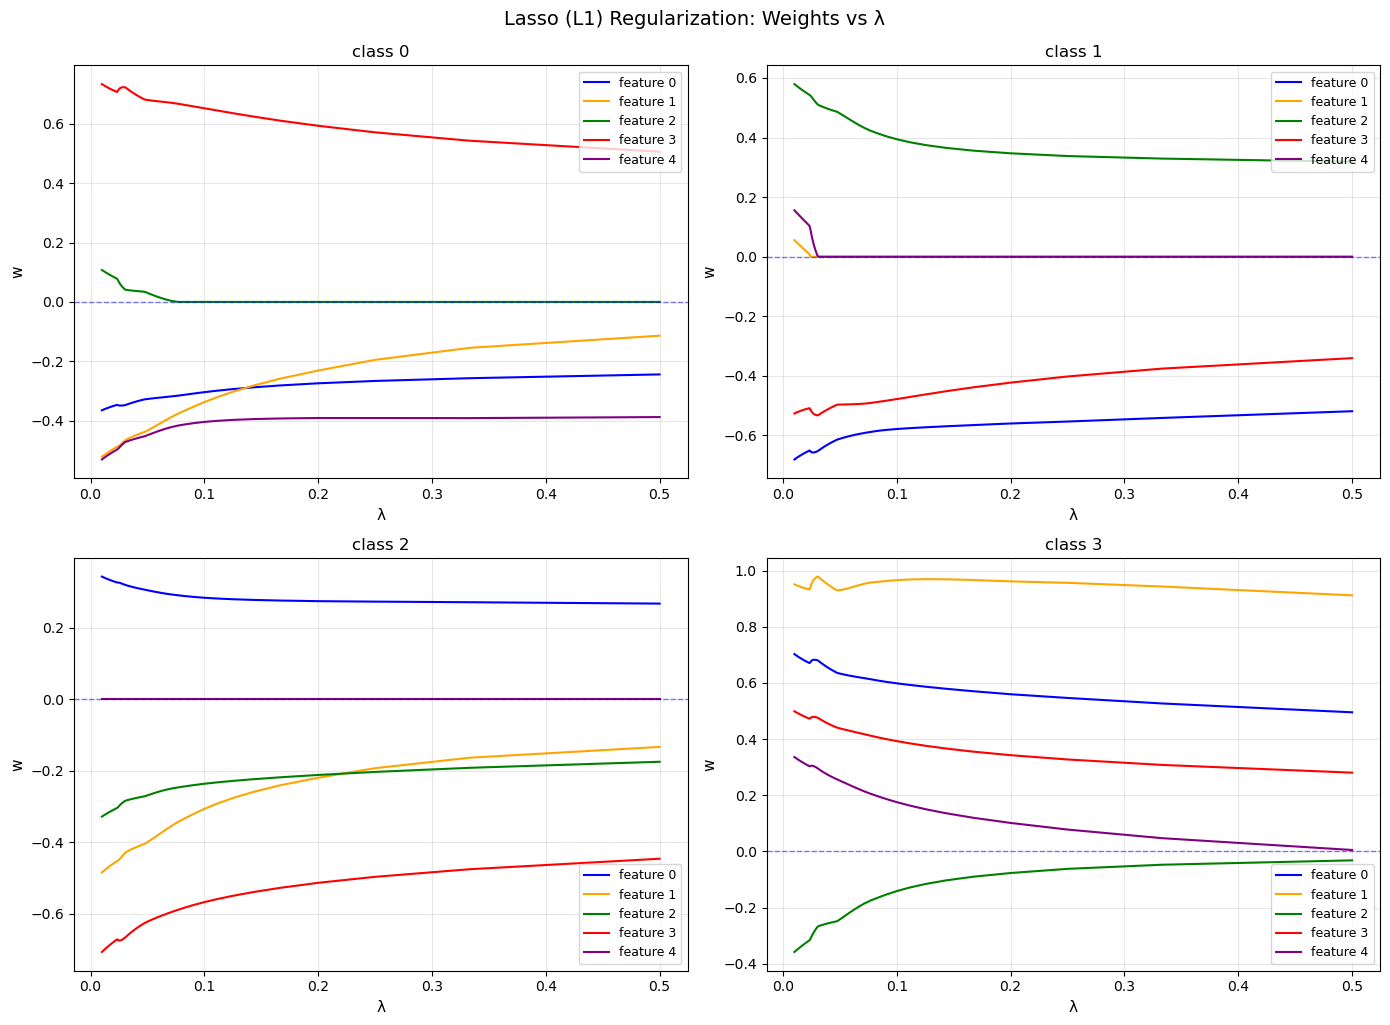

Figure: Weights versus regularization strength for each class (L1 penalty)


In [15]:
# Create plots for L1 regularization
# Graphing implementation borrowed from my previous semester's CS 513 Data-Mining Homework
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

colors = ['blue', 'orange', 'green', 'red', 'purple']

# Plot each class in a separate subplot
for class_idx in range(n_classes_lr):
    ax = axes[class_idx]
    
    # Plot weights for each feature
    for feature_idx in range(n_features_lr):
        ax.plot(lambda_values, weights_l1[:, class_idx, feature_idx],
               label=f'feature {feature_idx}', color=colors[feature_idx],
               linewidth=1.5)
    
    # Add horizontal line at w = 0
    ax.axhline(y=0, color='blue', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('λ', fontsize=11)
    ax.set_ylabel('w', fontsize=11)
    ax.set_title(f'class {class_idx}', fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Lasso (L1) Regularization: Weights vs λ', 
             fontsize=14, y=1.02)
plt.show()

print("Figure: Weights versus regularization strength for each class (L1 penalty)")

### Part b: Identify Unimportant Features [10 pts]
Explain which features, if any, are unimportant for each class

**Explanation:**

Lasso (L1) regularization encourages sparse solutions by driving some weights exactly to zero. Features with weights at or near zero can be considered unimportant for that particular class, as they don't contribute significantly to the classification decision. This property makes L1 regularization useful for feature selection as we can identify and potentially remove features that don't help distinguish a particular class from others.

If we look at the graphs above:

**Class 0:** Feature 2 (green line) converges to 0 as lambda increases, indicating to us that it is unimportant for classifying this class.

**Class 1:** Feature 4 (purple line) converges to 0, which shows us it does not contribute to distinguishing this class.

**Class 2:** Feature 4 (purple line) converges to 0 at higher regularization strength, making it unimportant for this class.

**Class 3:** Feature 4 (purple line) converges close to 0, suggesting it is not needed for classification.

### Part c: Ridge Regularization (L2) [10 pts]
Repeat part a using Ridge regularization to show it doesn't provide sparse solutions

In [16]:
# Store weights for Ridge (L2) regularization
weights_l2 = np.zeros((len(C_values), n_classes_lr, n_features_lr))

# Train models with L2 penalty
for idx, C in enumerate(C_values):
    clf = LogisticRegression(penalty='l2', solver='saga', C=C,
                             max_iter=10000, random_state=42)
    clf.fit(X_lr, y_lr)
    weights_l2[idx] = clf.coef_

print(f"Weights array shape: {weights_l2.shape}")

Weights array shape: (99, 4, 5)


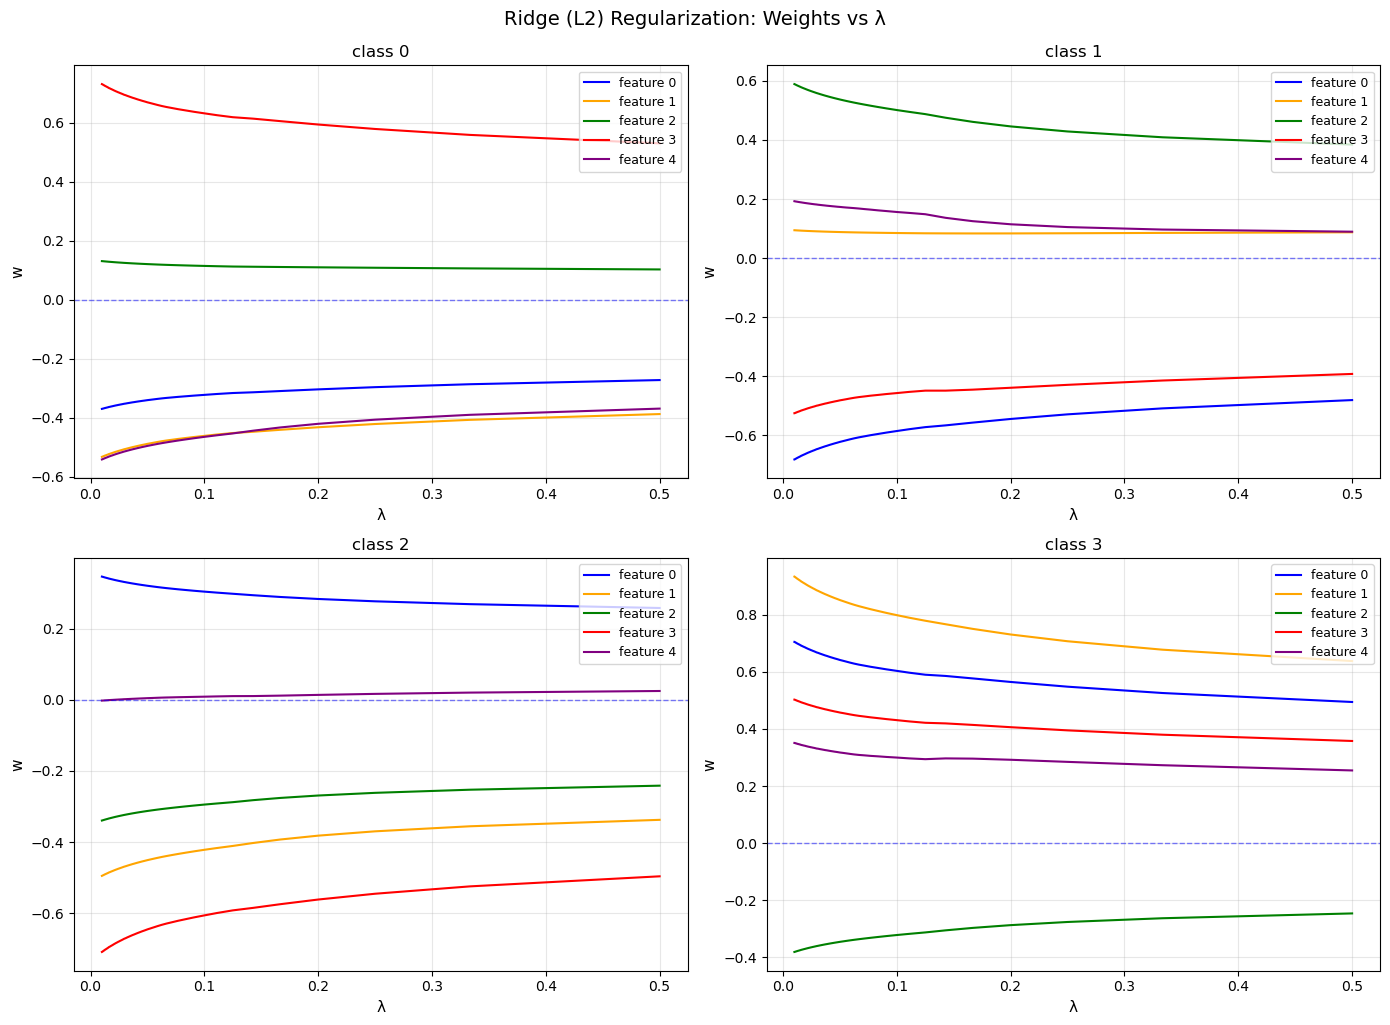

Figure: Weights versus regularization strength for each class (L2 penalty)


In [17]:
# Create plots for L2 regularization
# Graphing implementation borrowed from my previous semester's CS 513 Data-Mining Homework
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Plot each class in a separate subplot
for class_idx in range(n_classes_lr):
    ax = axes[class_idx]
    
    # Plot weights for each feature
    for feature_idx in range(n_features_lr):
        ax.plot(lambda_values, weights_l2[:, class_idx, feature_idx],
               label=f'feature {feature_idx}', color=colors[feature_idx],
               linewidth=1.5)
    
    # Add horizontal line at y = 0
    ax.axhline(y=0, color='blue', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('λ', fontsize=11)
    ax.set_ylabel('w', fontsize=11)
    ax.set_title(f'class {class_idx}', fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Ridge (L2) Regularization: Weights vs λ', 
             fontsize=14, y=1.02)
plt.show()

print("Figure: Weights versus regularization strength for each class (L2 penalty)")

**Conclusion:**

Ridge (L2) regularization shrinks weights but does NOT drive them to exactly zero.

All features retain some non-zero weight, making L2 unsuitable for feature selection.

With that being said, Lasso (L1) creates sparse solutions by forcing some weights to zero.